In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../outputs/merged_data.csv')

print("Shape:", df.shape)
print("Fraud rate:", round(df['isFraud'].mean() * 100, 2), "%")

Shape: (590540, 434)
Fraud rate: 3.5 %


In [2]:
# Columns reserved for NLP module (notebook 03)
nlp_cols = ['P_emaildomain', 'R_emaildomain', 'DeviceInfo']

# Columns to drop entirely
drop_cols = ['TransactionID', 'isFraud'] + nlp_cols

# Features and target
X = df.drop(columns=drop_cols)
y = df['isFraud']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Fraud cases:", y.sum())

Feature matrix shape: (590540, 429)
Target shape: (590540,)
Fraud cases: 20663


In [3]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']


/var/folders/pd/j9xkws912y56qb32qqkxc0gm0000gn/T/ipykernel_61922/3468645267.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


In [4]:
cat_cols = X.select_dtypes(include='str').columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    X[col] = X[col].fillna('missing')
    X[col] = le.fit_transform(X[col])

print("Encoding done")
print("Any remaining object columns:", X.select_dtypes(include='str').columns.tolist())

Encoding done
Any remaining object columns: []


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train fraud rate:", round(y_train.mean() * 100, 2), "%")
print("Test fraud rate:", round(y_test.mean() * 100, 2), "%")

Train shape: (472432, 429)
Test shape: (118108, 429)
Train fraud rate: 3.5 %
Test fraud rate: 3.5 %


In [10]:
from xgboost import XGBClassifier

# scale_pos_weight balances the classes: ratio of negative to positive
scale = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale, 2))

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)

model.fit(X_train, y_train, 
          eval_set=[(X_test, y_test)], 
          verbose=50)

scale_pos_weight: 27.58
[0]	validation_0-auc:0.84115
[50]	validation_0-auc:0.89334
[100]	validation_0-auc:0.90913
[150]	validation_0-auc:0.91791
[200]	validation_0-auc:0.92430
[250]	validation_0-auc:0.92891
[299]	validation_0-auc:0.93298


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [11]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.933

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95    113975
           1       0.24      0.81      0.37      4133

    accuracy                           0.90    118108
   macro avg       0.62      0.86      0.66    118108
weighted avg       0.97      0.90      0.93    118108


Confusion Matrix:
[[103353  10622]
 [   771   3362]]


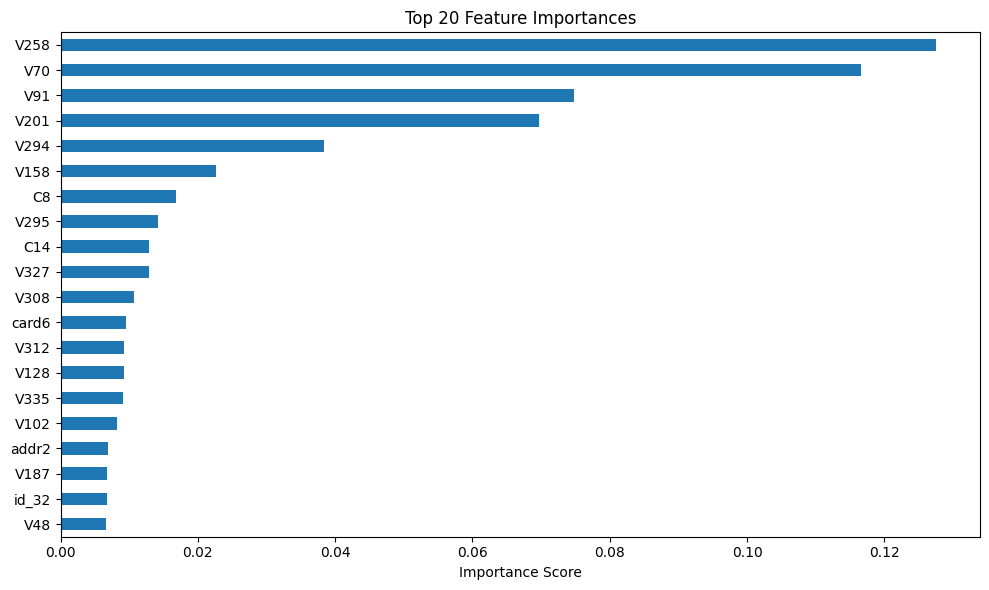

V258     0.127566
V70      0.116552
V91      0.074854
V201     0.069668
V294     0.038359
V158     0.022571
C8       0.016836
V295     0.014255
C14      0.012941
V327     0.012863
V308     0.010738
card6    0.009467
V312     0.009297
V128     0.009229
V335     0.009120
V102     0.008211
addr2    0.006926
V187     0.006804
id_32    0.006722
V48      0.006648
dtype: float32


In [12]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
top20 = importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()
print(top20)

/Users/adityaailsingnani/Desktop/Projects/Multimodal_Fraud_Detection/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


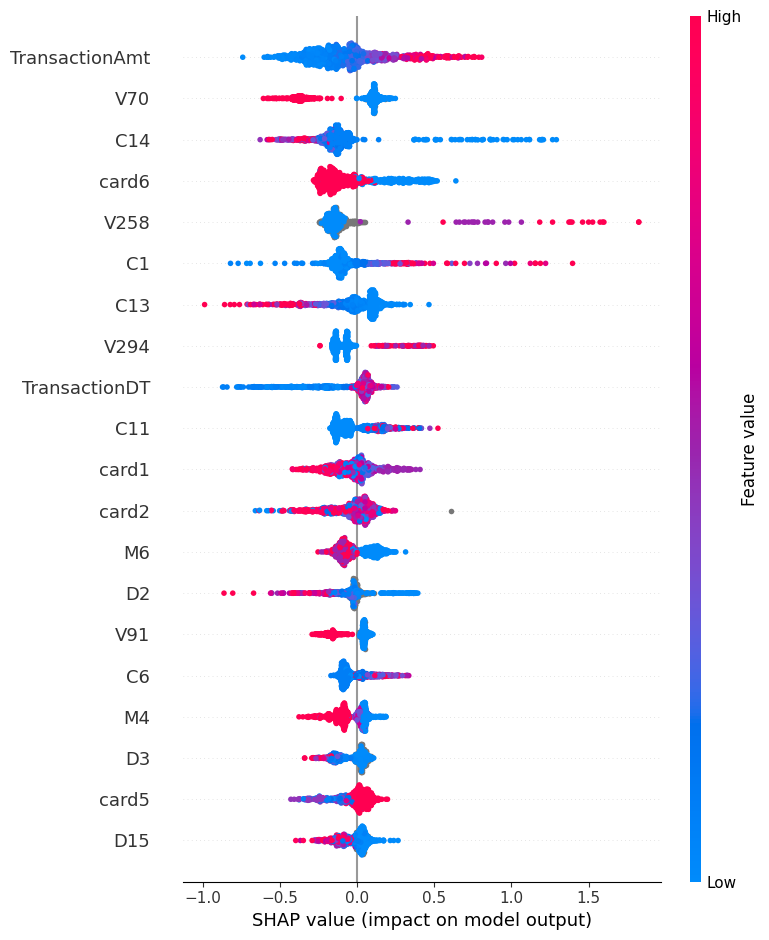

SHAP summary plot saved


In [13]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:1000])

shap.summary_plot(shap_values, X_test.iloc[:1000], max_display=20, show=False)
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=150)
plt.show()
print("SHAP summary plot saved")

## Tabular Model Results

- **ROC-AUC: 0.933** on held-out test set
- **Recall on fraud: 0.81** — catching 81% of actual fraud cases
- Class imbalance handled via `scale_pos_weight = 27.58` (ratio of legitimate to fraud transactions)
- Top predictors: TransactionAmt, V70, V258, C14, C1 — SHAP confirms high transaction 
  amounts and high account linkage counts are the strongest fraud signals
- V-series features (Vesta engineered) dominate importance but C-series count features 
  are the most interpretable signal

In [14]:
import joblib

joblib.dump(model, '../outputs/xgb_fraud_model.pkl')
print("Model saved")

Model saved
